In [113]:
from qubo.MaxCut import generate, solve_bruteforce, maxcut_value
from quantum.backend import get_simulator
from quantum.circuit import build_brickwall, build_circuit
from quantum.hamiltonian import build_maxcut_hamiltonian, update_hamiltonian

from optimizer.adam_spsa import optimize
from ndar.run import sample_theta_full


from pathlib import Path
import numpy as np
import pandas as pd

In [ ]:
# ============================================================
# 1) PARAMETERS
# ============================================================
n_qubits = 20
shots = 1000
depth = 1
seed = 1924
edge_prob = 0.8

K = 5
n_epochs = 10            # per outer iteration
total_baseline_epochs = K * n_epochs

adam_lr = 0.1
adam_beta1 = 0.9
adam_beta2 = 0.999
adam_eps = 1e-8

spsa_c = 0.15
spsa_gamma = 0.101

#out_dir = Path("maxcut_ndar_vs_plain_adam")
#out_dir.mkdir(exist_ok=True)

rng = np.random.default_rng(seed)

In [115]:
simulator = get_simulator(n_qubits=n_qubits)

In [116]:
edges = generate(
    n_qubits=n_qubits,
    edge_prob=edge_prob,
    rng=rng,
    weight_mode="unit",
)

In [117]:
def adjacency_matrix_from_edges(n_qubits, edges):
    A = np.zeros((n_qubits, n_qubits), dtype=float)
    for i, j, w in edges:
        A[i, j] = w
        A[j, i] = w
    return A


A = adjacency_matrix_from_edges(n_qubits, edges)

In [118]:
ansatz, params = build_brickwall(n_qubits, depth)

transpiled_circuit = build_circuit(n_qubits=n_qubits, ansatz=ansatz, simulator=simulator, seed=seed)


In [119]:
H_initial, H_constant_term_initial, H_zz_terms_initial = build_maxcut_hamiltonian(n_qubits, edges)


In [120]:
E_GS_exact, exact_ground_states = solve_bruteforce(
    n_qubits=n_qubits,
    constant_term=H_constant_term_initial,
    zz_terms=H_zz_terms_initial,
)

maxcut_exact = -E_GS_exact

exact_info = {
    "exact_ground_energy": float(E_GS_exact),
    "exact_maxcut": float(maxcut_exact),
    "degeneracy": int(len(exact_ground_states)),
    "ground_states_q0_first": exact_ground_states[:50],
}
print(exact_info)

{'exact_ground_energy': -92.0, 'exact_maxcut': 92.0, 'degeneracy': 52, 'ground_states_q0_first': ['11010011110000110000', '01010011111000110000', '11010011111000110000', '01110011111000110000', '01010011111010110000', '01100011111001110000', '01110011011001011000', '01100011111000111000', '01001111110000110100', '00111100001111000110', '00101100101011100110', '00011100100111100110', '01001111110000010110', '00101110001011010110', '00011101000111010110', '01001110110000110110', '01001101110000110110', '01001011110000110110', '00001111110000110110', '01001111110000110110', '01101100110001001110', '00101100001111001110', '01101000110001101110', '01001100110001101110', '00101100110001101110', '01101100110001101110', '10010011001110010001', '11010011001110010001', '10110011001110010001', '10010111001110010001', '11010011110000110001', '10010011001110110001', '10110000001111001001', '11110000001111001001', '10110100001111001001', '10110010001111001001', '10110001001111001001', '1110001011100

In [121]:
A = adjacency_matrix_from_edges(n_qubits, edges)
#pd.DataFrame(A).to_csv(out_dir / "adjacency_matrix.csv", index=False)


# ============================================================
# 5) PARAMETRIC BRICKWALL ANSATZ
# ============================================================

n_params = len(params)




#with open(out_dir / "exact_solution.json", "w", encoding="utf-8") as f:
#    json.dump(exact_info, f, indent=2, ensure_ascii=False)
#
#print("=" * 80)
#print("EXACT ANALYTICAL SOLUTION")
#print("=" * 80)
#print("Exact ground energy =", E_GS_exact)
#print("Exact maxcut        =", maxcut_exact)
#print("Degeneracy          =", len(exact_ground_states))
#print("Example ground state =", exact_ground_states[0])
#print()

In [122]:
#ndar_dir = out_dir / "ndar_method"
#ndar_dir.mkdir(exist_ok=True)

theta_init_shared = rng.uniform(-0.1, 0.1, size=n_params)
theta_current = theta_init_shared.copy()

current_H_sparse = H_initial
current_H_constant = H_constant_term_initial
current_H_terms = H_zz_terms_initial.copy()

ndar_rows = []
ndar_ratio_distributions = []
ndar_training_histories = []

#with open(ndar_dir / "hamiltoniano_inicial.json", "w", encoding="utf-8") as f:
#    json.dump(
#        serialize_hamiltonian(current_H_sparse, current_H_constant, current_H_terms),
#        f,
#        indent=2,
#        ensure_ascii=False,
#    )

In [123]:
# for k_iter in range(K):
#     print("=" * 80)
#     print(f"NDAR OUTER ITERATION {k_iter + 1}/{K}")
#     print("=" * 80)

#     #iter_dir = ndar_dir / f"iter_{k_iter:03d}"
#     #iter_dir.mkdir(exist_ok=True)

#     #with open(iter_dir / "hamiltoniano_antes.json", "w", encoding="utf-8") as f:
#     #    json.dump(
#     #        serialize_hamiltonian(current_H_sparse, current_H_constant, current_H_terms),
#     #        f,
#     #        indent=2,
#     #        ensure_ascii=False,
#     #    )
    
#     train_result = optimize(
#         label=f"NDAR_iter_{k_iter}",
#         theta_init=theta_current,
#         transpiled_measured_template=transpiled_circuit,
#         ansatz_params=params,
#         simulator=simulator,
#         shots=shots,
#         H_constant_term=current_H_constant,
#         H_zz_terms=current_H_terms,
#         out_dir_sub=None,#iter_dir,
#         seed_base=seed + 1000 * (k_iter + 1),
#         n_epochs=n_epochs,
#         lr=adam_lr,
#         beta1=adam_beta1,
#         beta2=adam_beta2,
#         eps=adam_eps,
#         spsa_c=spsa_c,
#         spsa_gamma=spsa_gamma,
#     )

#     theta_current = train_result["theta_best"].copy()
#     ndar_training_histories.append(train_result["df_train"].copy())

#     sample_result = sample_theta_full(
#         n_qubits=n_qubits,
#         E_GS_exact= E_GS_exact,
#         theta=theta_current,
#         iter_label=f"NDAR_iter_{k_iter}",
#         transpiled_measured_template=transpiled_circuit,
#         ansatz_params=params,
#         simulator=simulator,
#         shots=shots,
#         seed_simulator=seed + 500000 + k_iter,
#         edges=edges,
#         H_constant_term=current_H_constant,
#         H_zz_terms=current_H_terms,
#         out_dir_sub=None#iter_dir,
#     )

#     best_bitstring = sample_result["best_bitstring"]

#     ndar_rows.append(
#         {
#             "iteration": k_iter,
#             "cumulative_epochs": (k_iter + 1) * n_epochs,
#             "best_bitstring": best_bitstring,
#             "min_energy": sample_result["min_energy"],
#             "expected_energy": sample_result["expected_energy"],
#             "best_cut": sample_result["best_cut"],
#             "best_ratio": sample_result["best_ratio"],
#             "expected_ratio": sample_result["expected_ratio"],
#             "zero_ratio": sample_result["zero_ratio"],
#             "best_train_loss": train_result["best_loss"],
#             "best_epoch": train_result["best_epoch"],
#         }
#     )

#     ndar_ratio_distributions.append(sample_result["ratios"])

#     next_H_sparse, next_H_constant, next_H_terms = update_hamiltonian(
#         n_qubits=n_qubits,
#         constant_term=current_H_constant,
#         zz_terms=current_H_terms,
#         bitstring_q0_first=best_bitstring,
#     )

#     #with open(iter_dir / "hamiltoniano_seguinte.json", "w", encoding="utf-8") as f:
#     #    json.dump(
#     #        serialize_hamiltonian(next_H_sparse, next_H_constant, next_H_terms),
#     #        f,
#     #        indent=2,
#     #        ensure_ascii=False,
#     #    )

#     current_H_sparse = next_H_sparse
#     current_H_constant = next_H_constant
#     current_H_terms = next_H_terms.copy()
#     adam_lr = 0.75*adam_lr
# df_ndar = pd.DataFrame(ndar_rows)
# #df_ndar.to_csv(ndar_dir / "ndar_summary.csv", index=False)

# #with open(ndar_dir / "hamiltoniano_final.json", "w", encoding="utf-8") as f:
# #    json.dump(
# #        serialize_hamiltonian(current_H_sparse, current_H_constant, current_H_terms),
# #        f,
# #        indent=2,
# #        ensure_ascii=False,
# #    )


In [ ]:
def xor_bitstrings(a, b):
    return "".join("1" if x != y else "0" for x, y in zip(a, b))

cumulative_gauge = "0" * n_qubits

for k_iter in range(K):
    print("=" * 80)
    print(f"NDAR OUTER ITERATION {k_iter + 1}/{K}")
    print("=" * 80)

    #iter_dir = ndar_dir / f"iter_{k_iter:03d}"
    #iter_dir.mkdir(exist_ok=True)

    #with open(iter_dir / "hamiltoniano_antes.json", "w", encoding="utf-8") as f:
    #    json.dump(
    #        serialize_hamiltonian(current_H_sparse, current_H_constant, current_H_terms),
    #        f,
    #        indent=2,
    #        ensure_ascii=False,
    #    )
    if k_iter == 5: adam_lr/=2
    train_result = optimize(
        label=f"NDAR_iter_{k_iter}",
        theta_init=theta_current,
        transpiled_measured_template=transpiled_circuit,
        ansatz_params=params,
        simulator=simulator,
        shots=shots,
        H_constant_term=current_H_constant,
        H_zz_terms=current_H_terms,
        out_dir_sub=None,  # iter_dir,
        seed_base=seed + 1000 * (k_iter + 1),
        n_epochs=n_epochs,
        lr=adam_lr,
        beta1=adam_beta1,
        beta2=adam_beta2,
        eps=adam_eps,
        spsa_c=spsa_c,
        spsa_gamma=spsa_gamma,
    )
    theta_current = theta_init_shared.copy()
    #theta_current = train_result["theta_best"].copy()
    ndar_training_histories.append(train_result["df_train"].copy())

    sample_result = sample_theta_full(
        n_qubits=n_qubits,
        E_GS_exact=E_GS_exact,
        theta=theta_current,
        iter_label=f"NDAR_iter_{k_iter}",
        transpiled_measured_template=transpiled_circuit,
        ansatz_params=params,
        simulator=simulator,
        shots=shots,
        seed_simulator=seed + 500000 + k_iter#,
        edges=edges,
        H_constant_term=current_H_constant,
        H_zz_terms=current_H_terms,
        out_dir_sub=None  # iter_dir,
    )

    # string no referencial atual do Hamiltoniano transformado
    best_bitstring_current = sample_result["best_bitstring"]

    # string decodificada de volta para o problema original
    best_bitstring = xor_bitstrings(best_bitstring_current, cumulative_gauge)

    # recalcula o cut no problema original
    best_cut = maxcut_value(best_bitstring, edges)

    ndar_rows.append(
        {
            "iteration": k_iter,
            "cumulative_epochs": (k_iter + 1) * n_epochs,
            "best_bitstring": best_bitstring,
            "min_energy": sample_result["min_energy"],
            "expected_energy": sample_result["expected_energy"],
            "best_cut": best_cut,
            "best_ratio": sample_result["best_ratio"],
            "expected_ratio": sample_result["expected_ratio"],
            "zero_ratio": sample_result["zero_ratio"],
            "best_train_loss": train_result["best_loss"],
            "best_epoch": train_result["best_epoch"],
        }
    )

    ndar_ratio_distributions.append(sample_result["ratios"])

    next_H_sparse, next_H_constant, next_H_terms = update_hamiltonian(
        n_qubits=n_qubits,
        constant_term=current_H_constant,
        zz_terms=current_H_terms,
        bitstring_q0_first=best_bitstring_current,
    )

    # atualiza a gauge acumulada
    cumulative_gauge = xor_bitstrings(cumulative_gauge, best_bitstring_current)

    #with open(iter_dir / "hamiltoniano_seguinte.json", "w", encoding="utf-8") as f:
    #    json.dump(
    #        serialize_hamiltonian(next_H_sparse, next_H_constant, next_H_terms),
    #        f,
    #        indent=2,
    #        ensure_ascii=False,
    #    )

    current_H_sparse = next_H_sparse
    current_H_constant = next_H_constant
    current_H_terms = next_H_terms.copy()
    #adam_lr = adam_lr

df_ndar = pd.DataFrame(ndar_rows)
#df_ndar.to_csv(ndar_dir / "ndar_summary.csv", index=False)

#with open(ndar_dir / "hamiltoniano_final.json", "w", encoding="utf-8") as f:
#    json.dump(
#        serialize_hamiltonian(current_H_sparse, current_H_constant, current_H_terms),
#        f,
#        indent=2,
#        ensure_ascii=False,
#    )

NDAR OUTER ITERATION 1/6
NDAR_iter_0 | epoch=001 | loss=-13.564000 | best=-13.564000 | grad_norm=16.886563
NDAR_iter_0 | epoch=002 | loss=-15.146000 | best=-15.146000 | grad_norm=42.937597
NDAR_iter_0 | epoch=003 | loss=-17.192000 | best=-17.192000 | grad_norm=25.463827
NDAR_iter_0 | epoch=004 | loss=-19.118000 | best=-19.118000 | grad_norm=72.168840
NDAR_iter_0 | epoch=005 | loss=-21.354000 | best=-21.354000 | grad_norm=83.611009
NDAR_iter_0 | epoch=006 | loss=-23.623000 | best=-23.623000 | grad_norm=37.820200
NDAR_iter_0 | epoch=007 | loss=-25.786000 | best=-25.786000 | grad_norm=84.294457
NDAR_iter_0 | epoch=008 | loss=-28.053000 | best=-28.053000 | grad_norm=38.441052
NDAR_iter_0 | epoch=009 | loss=-30.833000 | best=-30.833000 | grad_norm=12.028277
NDAR_iter_0 | epoch=010 | loss=-33.006000 | best=-33.006000 | grad_norm=93.584640
NDAR OUTER ITERATION 2/6
NDAR_iter_1 | epoch=001 | loss=-65.745000 | best=-65.745000 | grad_norm=4.490434
NDAR_iter_1 | epoch=002 | loss=-66.107000 | best=

In [125]:
def plot_side_histograms(
    ax,
    x_positions,
    ratio_distributions,
    best_ratios,
    zero_ratios,
    title,
):
    ax.axhline(1.0, color="black", linestyle="--", linewidth=1.2, alpha=0.8)

    for idx, (x0, ratios) in enumerate(zip(x_positions, ratio_distributions)):
        ratios = np.asarray(ratios, dtype=float)

        bins = np.linspace(0.0, 1.02, 45)
        hist, edges = np.histogram(ratios, bins=bins)
        centers = 0.5 * (edges[:-1] + edges[1:])

        if hist.max() > 0:
            widths = 0.8 * hist / hist.max()
        else:
            widths = np.zeros_like(hist, dtype=float)

        if idx == 0:
            color = "red"
        elif idx == len(x_positions) - 1:
            color = "blue"
        else:
            color = "green"

        for c, w in zip(centers, widths):
            if w > 0:
                ax.hlines(y=c, xmin=x0, xmax=x0 + w, color=color, alpha=0.7, linewidth=1.7)

    ax.step(x_positions, best_ratios, where="mid", color="black", linestyle=":", linewidth=4)
    ax.scatter(x_positions, best_ratios, color="cyan", s=60, label="Best AR", zorder=5)
    ax.scatter(x_positions, zero_ratios, color="purple", s=60, label=r"$|0\ldots0\rangle$ AR", zorder=5)

    ax.set_xlabel("NDAR Iteration")
    ax.set_ylabel(r"Approximation Ratio $(E/E_{\mathrm{GS}})$")
    ax.set_title(title)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(min(x_positions) - 0.2, max(x_positions) + 1.0)
    ax.legend(loc="upper left")


x_ndar = np.arange(K)
best_ratios_ndar = df_ndar["best_ratio"].to_numpy()
zero_ratios_ndar = df_ndar["zero_ratio"].to_numpy()

In [126]:
import matplotlib.pyplot as plt

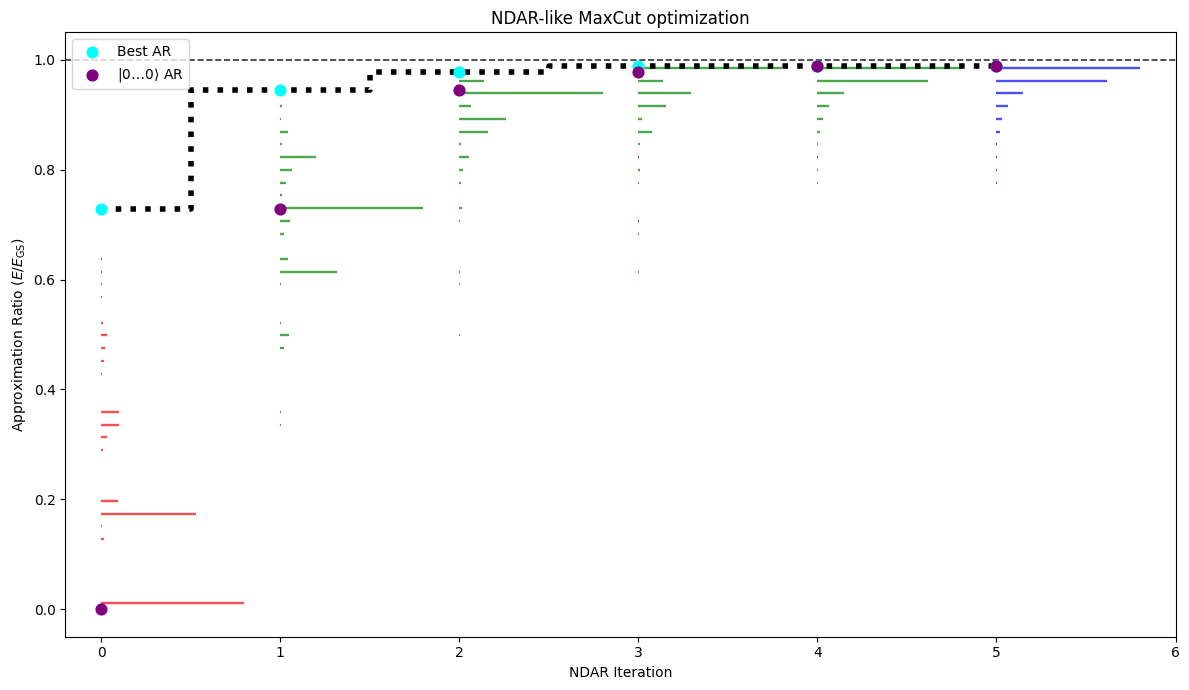

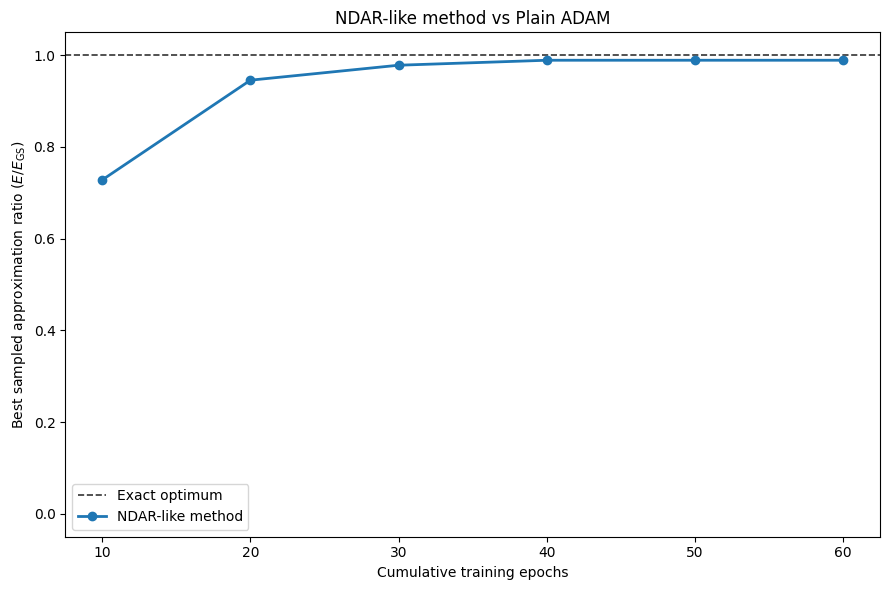

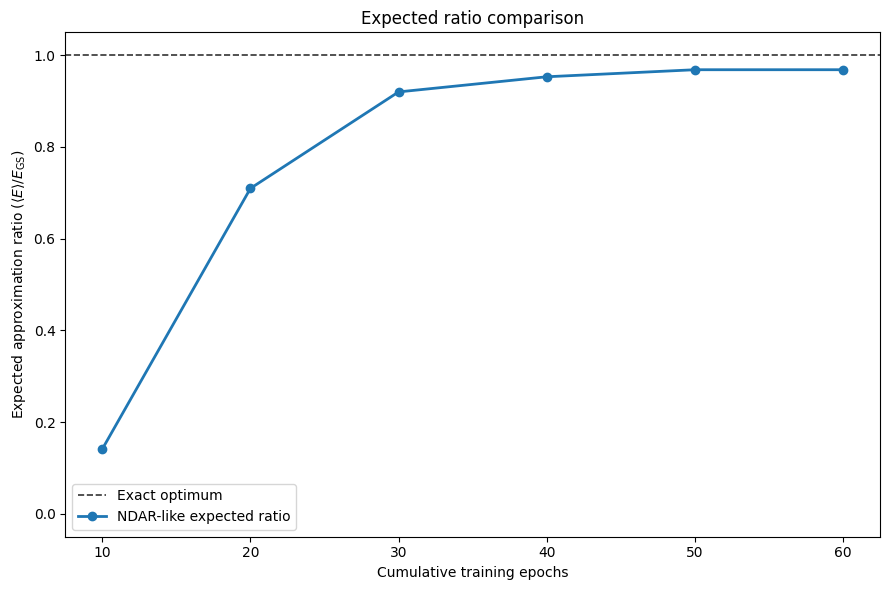

FINAL SUMMARY
Exact ground energy: -92.0
Exact maxcut: 92.0

NDAR summary:
   iteration  cumulative_epochs        best_bitstring  min_energy  \
0          0                 10  00110000000101100000       -67.0   
1          1                 20  10110000000101100011       -87.0   
2          2                 30  10110000000101101011       -90.0   
3          3                 40  10111000000101001111       -91.0   
4          4                 50  10111000000101001111       -91.0   
5          5                 60  10111000000101001111       -91.0   

   expected_energy  best_cut  best_ratio  expected_ratio  zero_ratio  \
0          -12.989      67.0    0.728261        0.141185   -0.000000   
1          -65.291      87.0    0.945652        0.709685    0.728261   
2          -84.647      90.0    0.978261        0.920076    0.945652   
3          -87.683      91.0    0.989130        0.953076    0.978261   
4          -89.097      91.0    0.989130        0.968446    0.989130   
5        

In [127]:
plt.figure(figsize=(12, 7))
ax = plt.gca()
plot_side_histograms(
    ax=ax,
    x_positions=x_ndar,
    ratio_distributions=ndar_ratio_distributions,
    best_ratios=best_ratios_ndar,
    zero_ratios=zero_ratios_ndar,
    title="NDAR-like MaxCut optimization",
)
plt.tight_layout()
#plt.savefig(out_dir / "ndar_like_approximation_ratio.png", dpi=200)
plt.show()


# ============================================================
# 14) DIRECT COMPARISON: NDAR VS PLAIN ADAM
# ============================================================
plt.figure(figsize=(9, 6))
plt.axhline(1.0, color="black", linestyle="--", linewidth=1.2, alpha=0.8, label="Exact optimum")

plt.plot(
    df_ndar["cumulative_epochs"],
    df_ndar["best_ratio"],
    marker="o",
    linewidth=2,
    label="NDAR-like method",
)

#plt.plot(
#    df_baseline["cumulative_epochs"],
#    df_baseline["best_ratio"],
#    marker="s",
#    linewidth=2,
#    label="Plain ADAM on fixed H",
#)

plt.xlabel("Cumulative training epochs")
plt.ylabel(r"Best sampled approximation ratio $(E/E_{\mathrm{GS}})$")
plt.title("NDAR-like method vs Plain ADAM")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.tight_layout()
#plt.savefig(out_dir / "ndar_vs_plain_adam.png", dpi=200)
plt.show()


# ============================================================
# 15) EXTRA COMPARISON: EXPECTED RATIO
# ============================================================
plt.figure(figsize=(9, 6))
plt.axhline(1.0, color="black", linestyle="--", linewidth=1.2, alpha=0.8, label="Exact optimum")

plt.plot(
    df_ndar["cumulative_epochs"],
    df_ndar["expected_ratio"],
    marker="o",
    linewidth=2,
    label="NDAR-like expected ratio",
)

#plt.plot(
#    df_baseline["cumulative_epochs"],
#    df_baseline["expected_ratio"],
#    marker="s",
#    linewidth=2,
#    label="Plain ADAM expected ratio",
#)

plt.xlabel("Cumulative training epochs")
plt.ylabel(r"Expected approximation ratio $(\langle E \rangle/E_{\mathrm{GS}})$")
plt.title("Expected ratio comparison")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.tight_layout()
#plt.savefig(out_dir / "expected_ratio_comparison.png", dpi=200)
plt.show()



print("=" * 80)
print("FINAL SUMMARY")
print("=" * 80)
print("Exact ground energy:", E_GS_exact)
print("Exact maxcut:", maxcut_exact)
print()
print("NDAR summary:")
print(df_ndar)
print()
print("Plain ADAM summary:")

print("=" * 80)

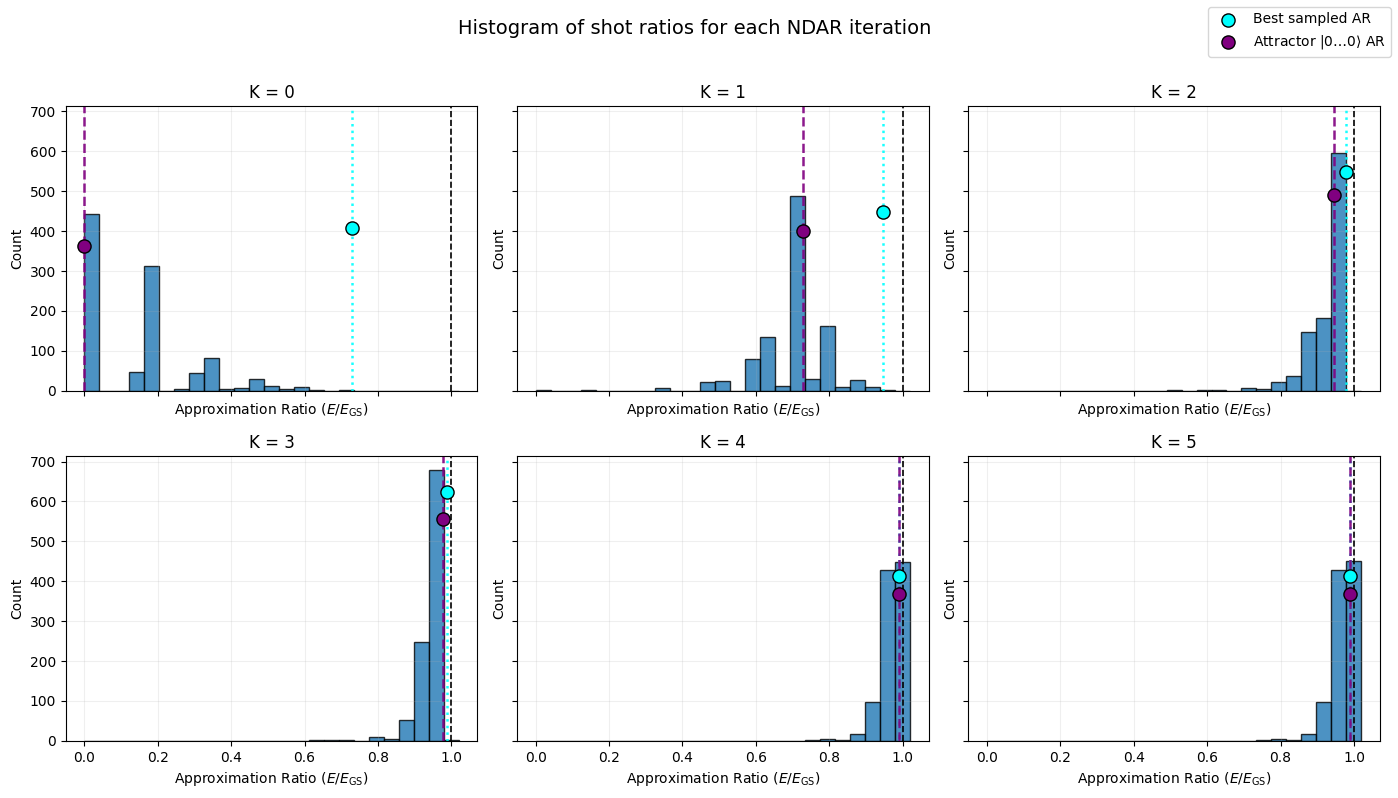

In [128]:
import numpy as np
import matplotlib.pyplot as plt
import math

best_ratios_ndar = df_ndar["best_ratio"].to_numpy()
zero_ratios_ndar = df_ndar["zero_ratio"].to_numpy()   # attractor

K = len(ndar_ratio_distributions)
ncols = 3
nrows = math.ceil(K / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(14, 4 * nrows),
    sharex=True,
    sharey=True
)
axes = np.array(axes).reshape(-1)

for k in range(K):
    ax = axes[k]
    ratios = np.asarray(ndar_ratio_distributions[k], dtype=float)

    # histogram
    counts, bins, _ = ax.hist(
        ratios,
        bins=25,
        range=(0.0, 1.02),
        edgecolor="black",
        alpha=0.8
    )

    # reference line for exact optimum
    ax.axvline(1.0, color="black", linestyle="--", linewidth=1.2)

    # choose a y-position near the top of the histogram to place the markers
    ymax = max(counts) if len(counts) > 0 else 1.0
    y_best = 0.92 * ymax
    y_attr = 0.82 * ymax

    # best sampled ratio = lowest sampled energy
    ax.scatter(
        best_ratios_ndar[k],
        y_best,
        color="cyan",
        s=90,
        edgecolors="black",
        zorder=5,
        label="Best sampled AR" if k == 0 else None
    )
    ax.axvline(
        best_ratios_ndar[k],
        color="cyan",
        linestyle=":",
        linewidth=1.8,
        alpha=0.9
    )

    # attractor ratio = |0...0> ratio under current transformed H
    ax.scatter(
        zero_ratios_ndar[k],
        y_attr,
        color="purple",
        s=90,
        edgecolors="black",
        zorder=5,
        label=r"Attractor $|0\ldots0\rangle$ AR" if k == 0 else None
    )
    ax.axvline(
        zero_ratios_ndar[k],
        color="purple",
        linestyle="--",
        linewidth=1.8,
        alpha=0.9
    )

    ax.set_title(f"K = {k}")
    ax.set_xlabel(r"Approximation Ratio $(E/E_{\mathrm{GS}})$")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.2)

for j in range(K, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="upper right")

plt.suptitle("Histogram of shot ratios for each NDAR iteration", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()